## Загрузка данных

Этот набор данных содержит информацию о заемщиках и их кредитной истории:
- Age (Возраст): возраст заемщика в годах.
- Sex (Пол): мужской (male) или женский (female).
- Job (Работа): профессиональная категория (от 0 до 3, где 0 — неквалифицированный/безработный, а 3 — высококвалифицированный специалист или руководитель).
- Housing (Жилье): тип владения жильем (own — свое, free — бесплатное, rent — аренда).
- Saving accounts (Сберегательные счета): уровень накоплений (little, moderate, quite rich, rich).
- Checking account (Текущий счет): наличие и состояние расчетного счета.
- Credit amount (Сумма кредита): размер запрашиваемого кредита в немецких марках (валюта оригинала).
- Duration (Длительность): срок кредита в месяцах.
- Purpose (Цель): на что берутся деньги (автомобиль, мебель, ремонт, бизнес, образование и т.д.).
- Risk (Риск): целевая переменная (good — надежный клиент, bad — потенциальный неплательщик).

Примечание: В столбцах Saving accounts и Checking account много пропусков (NaN), что обычно означает отсутствие счета у клиента.

In [1]:
import pandas as pd

df = pd.read_csv("data/german_credit_risk.csv", index_col=0)
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.0,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


#### Заполнение значением "unknown" столбцов Saving accounts и Checking account

In [3]:
cols_to_fix = ["Saving accounts", "Checking account"]

df[cols_to_fix] = df[cols_to_fix].fillna("unknown")
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,unknown,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,unknown,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


#### Конструирование признака "Платеж в месяц"

In [4]:
df["Monthly pay"] = df["Credit amount"] / df["Duration"]
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Monthly pay
0,67,male,2,own,unknown,little,1169,6,radio/TV,good,194.833333
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,123.979167
2,49,male,1,own,little,unknown,2096,12,education,good,174.666667
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,187.666667
4,53,male,2,free,little,little,4870,24,car,bad,202.916667
...,...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,unknown,1736,12,furniture/equipment,good,144.666667
996,40,male,3,own,little,little,3857,30,car,good,128.566667
997,38,male,2,own,little,unknown,804,12,radio/TV,good,67.000000
998,23,male,2,free,little,little,1845,45,radio/TV,bad,41.000000


#### Кодирование категориальных признаков

In [5]:
df["Risk"] = df["Risk"].map({"good": 1, "bad": 0})

# One-Hot Encoding — для признаков без явного порядка (Housing, Purpose)
# drop_first=True удаляет одну колонку, чтобы избежать мультиколлинеарности
df = pd.get_dummies(
    df,
    columns=["Housing", "Sex", "Checking account", "Saving accounts", "Purpose"],
    drop_first=True,
)
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1000 non-null   int64  
 1   Job                          1000 non-null   int64  
 2   Credit amount                1000 non-null   int64  
 3   Duration                     1000 non-null   int64  
 4   Risk                         1000 non-null   int64  
 5   Monthly pay                  1000 non-null   float64
 6   Housing_own                  1000 non-null   bool   
 7   Housing_rent                 1000 non-null   bool   
 8   Sex_male                     1000 non-null   bool   
 9   Checking account_moderate    1000 non-null   bool   
 10  Checking account_rich        1000 non-null   bool   
 11  Checking account_unknown     1000 non-null   bool   
 12  Saving accounts_moderate     1000 non-null   bool   
 13  Saving accounts_quite rich   1

,Age,Job,Credit amount,Duration,Risk,Monthly pay,Housing_own,Housing_rent,Sex_male,Checking account_moderate,...,Saving accounts_quite rich,Saving accounts_rich,Saving accounts_unknown,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,1,194.833333,True,False,True,False,...,False,False,True,False,False,False,False,True,False,False
1,22,2,5951,48,0,123.979167,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,1,174.666667,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,1,187.666667,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,0,202.916667,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31,1,1736,12,1,144.666667,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
996,40,3,3857,30,1,128.566667,True,False,True,False,...,False,False,False,True,False,False,False,False,False,False
997,38,2,804,12,1,67.000000,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
998,23,2,1845,45,0,41.000000,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


#### Матрица корреляции признаков

Матрица корреляции используется для поиска и оценки связей между признаками в данных.

Позволяет увидеть, какие признаки сильнее всего влияют на целевую переменную (Risk).

Помогает найти признаки, которые дублируют друг друга (сильно коррелируют между собой). Если два признака почти одинаковы, один из них можно удалить, чтобы упростить модель.

Позволяет проверить гипотезы (например, "зависит ли сумма кредита от возраста?").

На основе представленного графика можно сделать следующие выводы:
- самая сильная связь (положительная корреляция 0.62) между Credit amount (сумма) и Duration (срок). Чем больше сумма кредита, тем на более долгий срок его обычно берут. 
- наиболее заметное влияние на риск (целевая переменная Risk) оказывают параметры счетов: Checking account_unknown имеет корреляцию 0.32.
- видна сильная обратная связь между Housing_own (свое жилье) и Housing_rent (аренда) (значение -0.74): если у человека свое жилье, он обычно его не арендует.
- возраст (Age) и пол (Sex_male) имеют очень низкую корреляцию с остальными параметрами (почти везде значения близки к 0), что говорит об их самостоятельности в этом наборе данных.

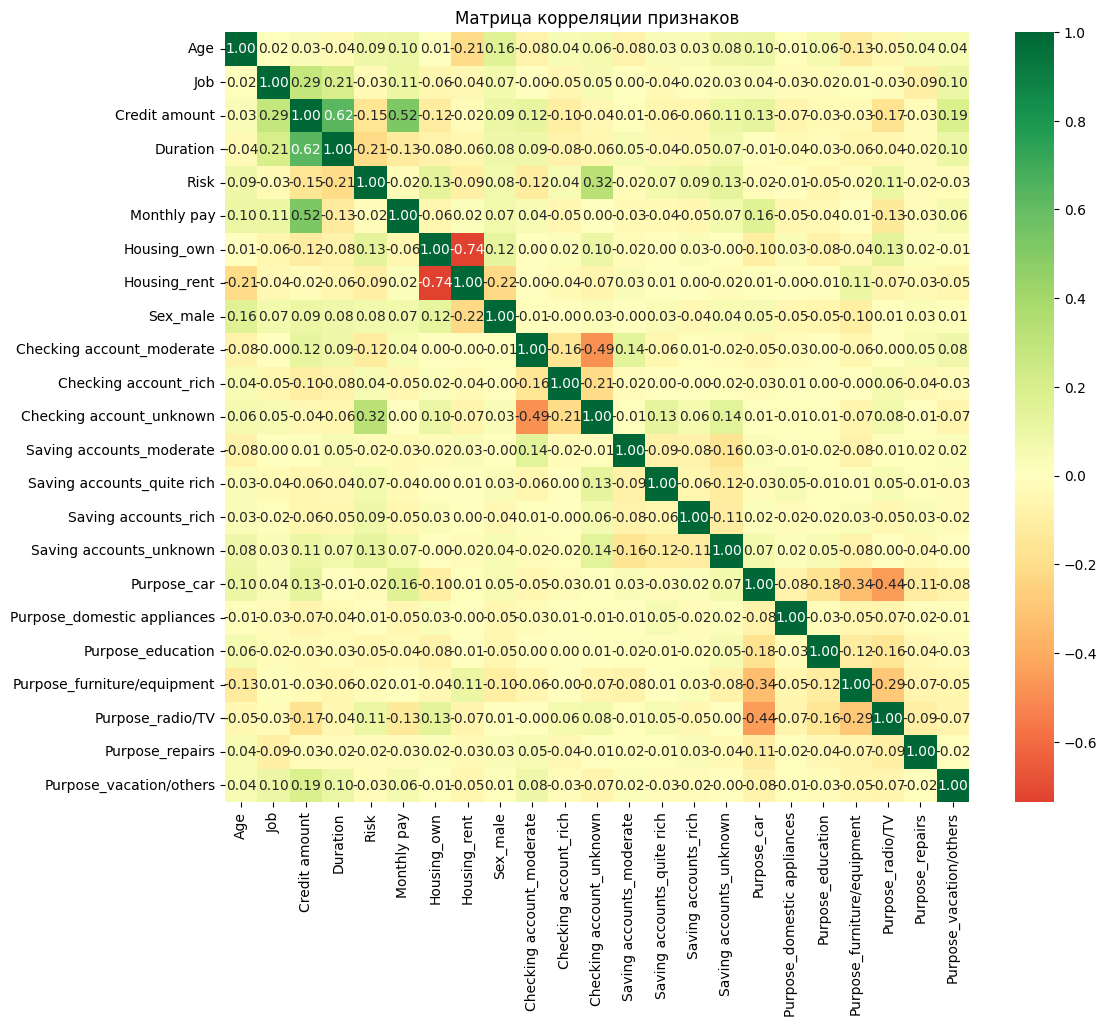

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
# Построение тепловой карты
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Матрица корреляции признаков")
plt.show()

#### Формирование обучающей и тестовой выборок

In [7]:
from sklearn.model_selection import train_test_split

seed = 42

X = df.drop("Risk", axis=1)
y = df["Risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

#### Обучение и оценка модели

Дерево решений выбрано из-за наглядности и простоты интерпретации результатов

Точность на обучении: 0.73
Точность на тесте: 0.73
              precision    recall  f1-score   support

     Bad (0)       0.54      0.64      0.58        59
    Good (1)       0.84      0.77      0.80       141

    accuracy                           0.73       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.73      0.74       200



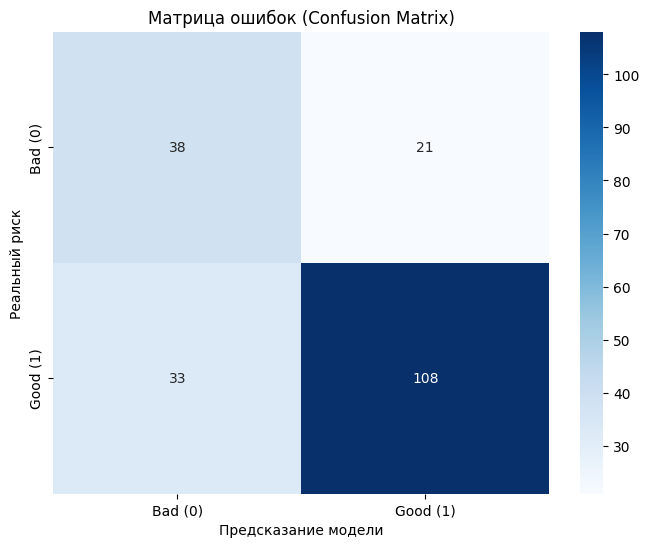

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Обучении и оценка дерева решений
tree_model = DecisionTreeClassifier(
    max_depth=3, class_weight="balanced", random_state=seed, ccp_alpha=0.0
)
tree_model.fit(X_train, y_train)
train_score = tree_model.score(X_train, y_train)
test_score = tree_model.score(X_test, y_test)

print(f"Точность на обучении: {train_score:.2f}")
print(f"Точность на тесте: {test_score:.2f}")

text_labels = ["Bad (0)", "Good (1)"]

y_pred = tree_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=text_labels))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=text_labels,
    yticklabels=text_labels,
)

plt.xlabel("Предсказание модели")
plt.ylabel("Реальный риск")
plt.title("Матрица ошибок (Confusion Matrix)")
plt.show()

#### Визуализация дерева

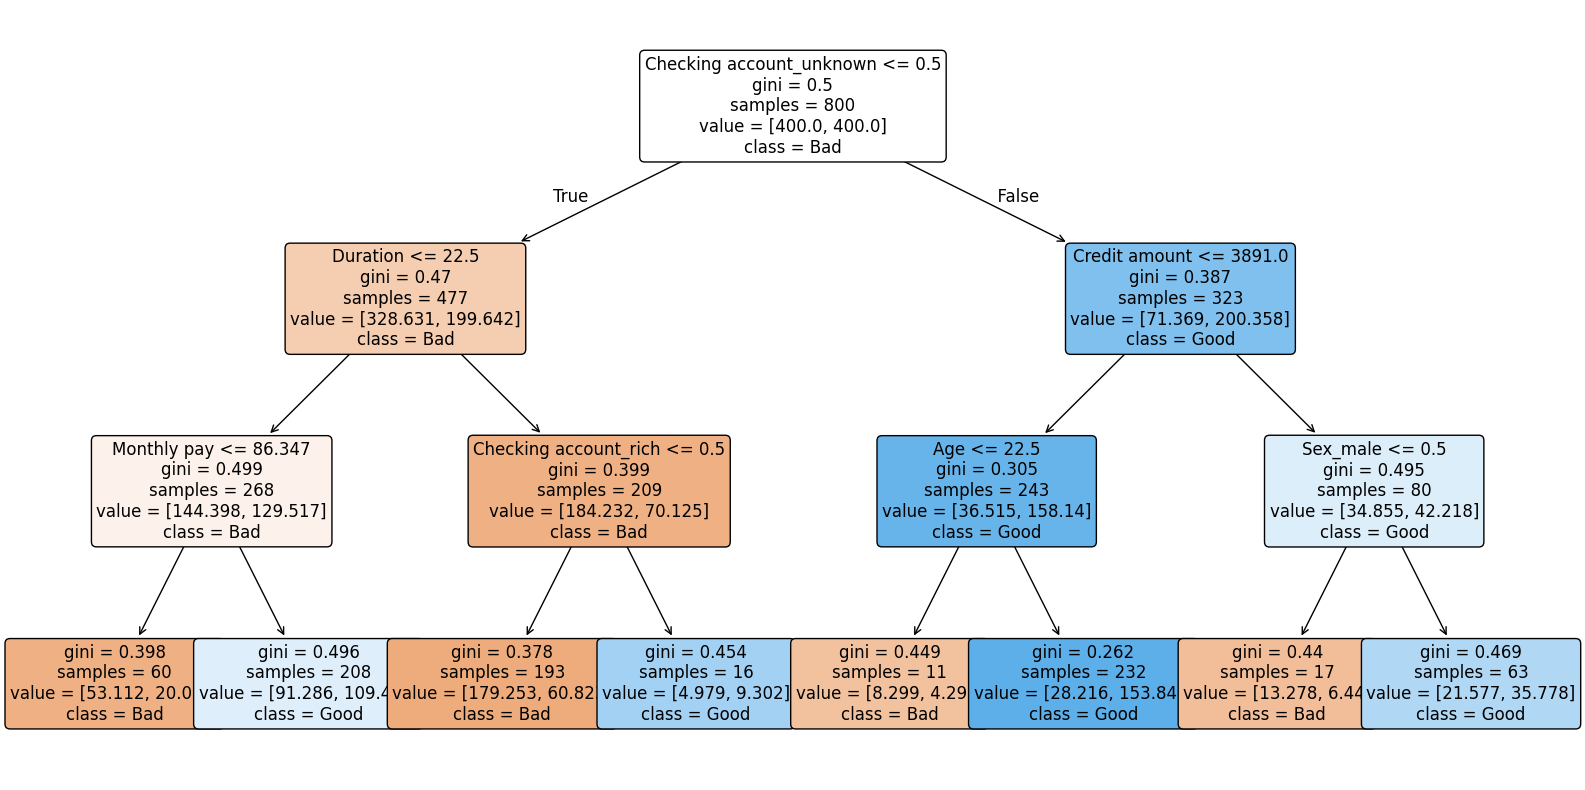

In [9]:
# Визуализируем структуру дерева
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=list(X.columns),
    class_names=["Bad", "Good"],
    filled=True,
    rounded=True,
    fontsize=12,
)
plt.show()

Основные правила, которые выстроило дерево:
1. Главный фактор - признак Checking account_unknown:
    - Если данные о счете есть (значение <= 0.5, левая ветка), то система сразу становится более подозрительной (базовый класс Bad).
    - Если данных о счете нет (значение > 0.5, правая ветка), то система считает клиента более надежным (базовый класс — Good).
2. Группа "Повышенного риска" (левая ветка). Если банк знает состояние счета клиента, дерево учитывает длительность кредита (Duration):
    - Если кредит дольше 22.5 месяцев и при этом у клиента не "богатый" счет (Checking account_rich <= 0.5), то модель уверенно ставит Bad. Это один из самых крупных "плохих" узлов (193 образца).
    - Если кредит короче (<=) 22.5 месяцев, но ежемесячный платеж (Monthly pay) низкий (<= 86.3), то дерево также часто прогнозирует Bad.
3. Группа "Надежных заемщиков" (правая ветка). Если данных о счете нет, дерево становится лояльнее и проверяет сумму кредита (Credit amount):
    - Если сумма кредита умеренная (<= 3819) и заемщик не совсем юный (Age > 22.5), то это самый надежный узел дерева (232 образца, класс Good).
    - Даже если по остальным параметрам всё хорошо, но заемщику меньше 22.5 лет, дерево видит в этом риск и относит к классу Bad (всего 11 человек).


Главная проблема данного дерева - признак Checking account_unknown.

Модель основана на закономерности: "Если мы ничего не знаем о счете клиента, то это хорошо".

Заемщику выгодно скрывать информацию о своих счетах, чтобы повысить свои шансы на одобрение.

В реальности отсутствие данных — это фактор неопределенности, который должен приводить к более строгой проверке, а не к автоматическому кредиту.

Если мы уберем из рассмотрения признак Checking account_unknown, то дерево полностью перестроится, и его точность упадет.

Это значит, что модель не нашла глубоких закономерностей в поведении людей, а просто используется особенность набора данных.

Дерево нашло кратчайший путь к высокой точности через некачественный признак полностью проигнорировав реальный финансовый профиль заемщика (доходы, историю, обязательства).

Модель "переобучилась" на специфике конкретного датасета и не может быть использована в реальности, так как её логика не поддается здравому объяснению.

#### Пример извлечения правил из обученного дерева решений

- Глубина дерева 3–4 даст небольшое количество легко интерпретируемых правил.
- Для признака X вычисляются 33-й и 66-й перцентили как границы термов.
- Для каждого признака и порога определяется, к какому терму относится это значение (например, если порог <= 33‑го перцентиля, то терм «низкий»; между 33 и 66 – «средний»; больше 66 – «высокий»).
- Каждая ветвь дерева формирует одно правило.

In [ ]:
import numpy as np

term_boundaries = {}
for col in X_train.columns:
    values = X_train[col]
    if type(values.tolist()[0]) is bool:
        term_boundaries[col] = (0, 1)
    else:
        q33 = values.quantile(0.33)
        q66 = values.quantile(0.66)
        term_boundaries[col] = (q33, q66)


# Функция-заглушка
def value_to_term(col: str, value: float, direction: str) -> str:
    """Преобразует числовой порог в название терма с учётом направления"""
    low, high = term_boundaries[col]
    if direction == "<=":
        if value <= low:
            return "низкий"
        elif value <= high:
            return "средний"
        else:
            return "высокий"
    elif value > high:
        return "высокий"
    elif value > low:
        return "средний"
    else:
        return "низкий"


rules = []


def recurse(node: int, conditions: list) -> None:
    if children_left[node] == -1 and children_right[node] == -1:  # лист
        class_idx = np.argmax(values[node][0])
        rule = {
            "conditions": conditions,
            "class": class_idx,
            "samples": tree.n_node_samples[node],
        }
        rules.append(rule)
    else:
        # левый потомок: условие признак <= порог
        cond_left = conditions.copy()
        feat = feature[node]
        feat_name = X_train.columns[feat]
        thr = threshold[node]
        term_left = value_to_term(feat_name, thr, "<=")
        cond_left.append((feat_name, term_left))
        recurse(children_left[node], cond_left)

        # правый потомок: условие признак > порог
        cond_right = conditions.copy()
        term_right = value_to_term(feat_name, thr, ">")
        cond_right.append((feat_name, term_right))
        recurse(children_right[node], cond_right)


tree = tree_model.tree_
children_left = tree.children_left
children_right = tree.children_right
feature = tree.feature
threshold = tree.threshold
values = tree.value

recurse(0, [])

for i, r in enumerate(rules):
    ante = " И ".join([f"{feat} = {term}" for feat, term in r["conditions"]])
    print(
        f"Правило {i + 1}: ЕСЛИ {ante} ТО класс = {r['class']} (вес = {r['samples']})"
    )

Правило 1: ЕСЛИ Checking account_unknown = средний И Duration = средний И Monthly pay = низкий ТО класс = 0 (вес = 60)
Правило 2: ЕСЛИ Checking account_unknown = средний И Duration = средний И Monthly pay = низкий ТО класс = 1 (вес = 208)
Правило 3: ЕСЛИ Checking account_unknown = средний И Duration = средний И Checking account_rich = средний ТО класс = 0 (вес = 193)
Правило 4: ЕСЛИ Checking account_unknown = средний И Duration = средний И Checking account_rich = средний ТО класс = 1 (вес = 16)
Правило 5: ЕСЛИ Checking account_unknown = средний И Credit amount = высокий И Age = низкий ТО класс = 0 (вес = 11)
Правило 6: ЕСЛИ Checking account_unknown = средний И Credit amount = высокий И Age = низкий ТО класс = 1 (вес = 232)
Правило 7: ЕСЛИ Checking account_unknown = средний И Credit amount = высокий И Sex_male = средний ТО класс = 0 (вес = 17)
Правило 8: ЕСЛИ Checking account_unknown = средний И Credit amount = высокий И Sex_male = средний ТО класс = 1 (вес = 63)


### Построение нечеткой системы

Система построена на базе трех "понятных" признаков:
- Duration (Срок),
- Monthly pay (Платеж),
- Savings (Сбережения).

Система работает по принципу "презумпции надежности", отказывая только при явном сочетании негативных факторов (высокая финансовая нагрузка при отсутствии накоплений).

Saving accounts является подходящим признаком, так как отражает реальные накопления клиента.

Если у человека есть сбережения, то риск падает по объективным причинам.

#### Определение статистики для основных входных переменных

Будет использовано для определения параметров функций принадлежности

In [11]:
# Считаем статистику для Duration
d_min, d_q1, d_q2, d_q3, d_max = df["Duration"].quantile([0, 0.25, 0.5, 0.75, 1])
display(d_min, d_q1, d_q2, d_q3, d_max)
# Считаем статистику для Monthly pay
m_min, m_q1, m_q2, m_q3, m_max = df["Monthly pay"].quantile([0, 0.25, 0.5, 0.75, 1])
display(m_min, m_q1, m_q2, m_q3, m_max)

4.0

12.0

18.0

24.0

72.0

24.055555555555557

89.60000000000001

130.33333333333331

206.18333333333334

2482.6666666666665

#### Настройка нечеткой системы

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

duration = ctrl.Antecedent(np.arange(d_min, d_max, 1), "duration")
monthly_pay = ctrl.Antecedent(np.arange(m_min, m_max, 1), "monthly_pay")
savings = ctrl.Antecedent(np.arange(0, 1.1, 0.1), "savings")
risk = ctrl.Consequent(np.arange(0, 1.1, 0.1), "risk")

# Переменные для Duration
duration["low"] = fuzz.trimf(duration.universe, [d_min, d_min, d_q2])
duration["medium"] = fuzz.trimf(duration.universe, [d_min, d_q2, d_max])
duration["high"] = fuzz.trimf(duration.universe, [d_q2, d_max, d_max])

# Переменные для Monthly pay
monthly_pay["low"] = fuzz.trimf(monthly_pay.universe, [m_min, m_min, m_q2])
monthly_pay["medium"] = fuzz.trimf(monthly_pay.universe, [m_min, m_q2, m_max])
monthly_pay["high"] = fuzz.trimf(monthly_pay.universe, [m_q2, m_max, m_max])

# Переменные для сбережений: 0 - мало или нет, 1 - есть ощутимые накопления (Moderate/Rich)
savings = ctrl.Antecedent(np.arange(0, 1.1, 0.1), "savings")
savings["low"] = fuzz.trimf(savings.universe, [0, 0, 0.6])
savings["high"] = fuzz.trimf(savings.universe, [0.4, 1, 1])

# Переменные для Risk
risk["bad"] = fuzz.trapmf(risk.universe, [0, 0, 0.2, 0.4])
risk["good"] = fuzz.trapmf(risk.universe, [0.4, 0.6, 1, 1])

# Правила
rules = [
    # Базовое одобрение - если есть сбережения ИЛИ короткий срок
    ctrl.Rule(savings["high"] | duration["low"], risk["good"]),
    # Запрет по сроку - длинный срок при отсутствии накоплений — это высокий риск
    ctrl.Rule(duration["high"] & savings["low"], risk["bad"]),
    # Запрет при фин. нагрузке - высокий ежемесячный платеж при отсутствии накоплений — это высокий риск
    ctrl.Rule(monthly_pay["high"] & savings["low"], risk["bad"]),
    # Уточнение пограничных случаев -  это правило помогает отсеивать сомнительных заемщиков
    # Если платеж СРЕДНИЙ и накоплений НЕТ — это тоже риск
    ctrl.Rule(monthly_pay["medium"] & savings["low"], risk["bad"]),
    # Абсолютный запрет
    # Максимальный срок И максимальный платеж — отказ даже при наличии накоплений
    ctrl.Rule(duration["high"] & monthly_pay["high"], risk["bad"]),
]

# Создаем систему управления
risk_ctrl = ctrl.ControlSystem(rules)
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

#### Визуализация нечетких переменных

/Users/user/Projects/python/mai-examples/lec3.2/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


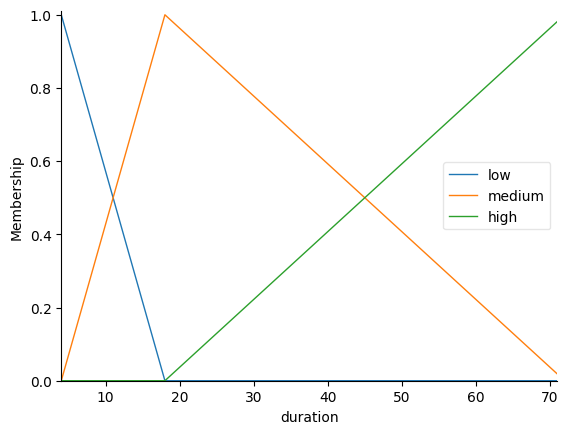

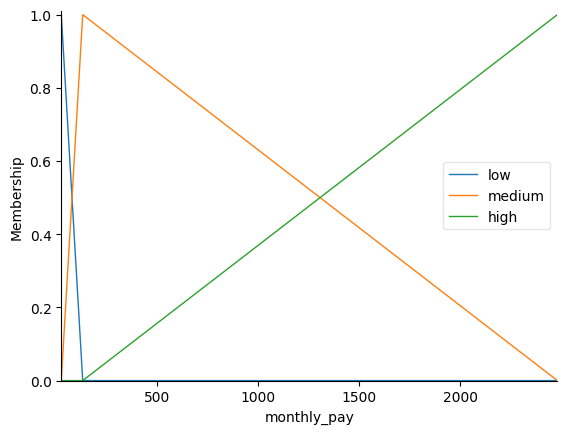

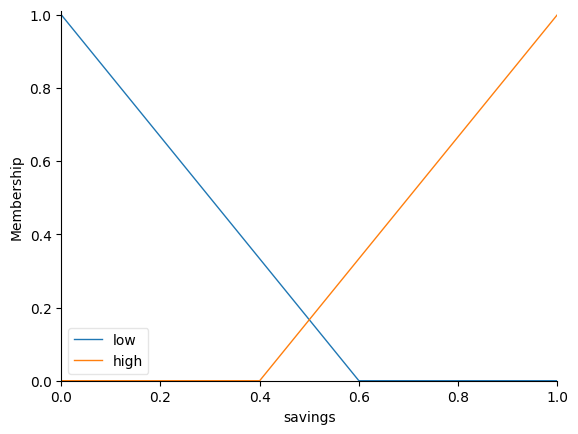

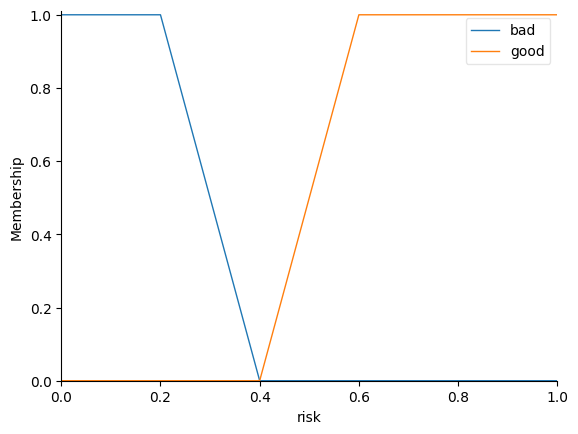

In [13]:
duration.view()
monthly_pay.view()
savings.view()
risk.view()

#### Тестирование и отладка нечеткой системы

 Antecedents 
Antecedent: savings                 = 0
  - low                             : 1.0
  - high                            : 0.0
Antecedent: duration                = 48
  - low                             : 0.0
  - medium                          : 0.4444444444444444
  - high                            : 0.5555555555555556
Antecedent: monthly_pay             = 150
  - low                             : 0.0
  - medium                          : 0.9916395068726087
  - high                            : 0.00836049312739125

 Rules 
RULE #0:
  IF savings[high] OR duration[low] THEN risk[good]
	AND aggregation function : fmin
	OR aggregation function  : fmax

  Aggregation (IF-clause):
  - savings[high]                                          : 0.0
  - duration[low]                                          : 0.0
                            savings[high] OR duration[low] = 0.0
  Activation (THEN-clause):
                                                risk[good] : 0.0

RULE #1:
  IF

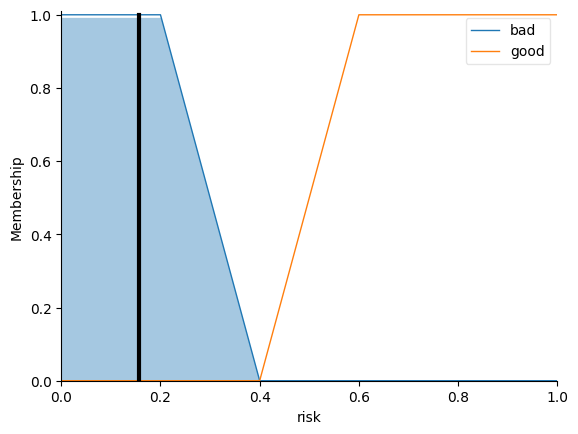

In [14]:
risk_sim.input["duration"] = 48
risk_sim.input["monthly_pay"] = 150
risk_sim.input["savings"] = 0
risk_sim.compute()
risk_sim.print_state()
print(f"Рассчитанный уровень риска: {risk_sim.output['risk']:.2f}")
risk.view(sim=risk_sim)

#### Функция для оценки качества нечеткой системы

Использование порога 0.3 вместо стандартных 0.5 в нечеткой системе — осознанный шаг для калибровки модели.

В данном случае, такой низкий порог делает процесс выдачи кредита очень строгим и осторожным.

Если оставить порог 0.5, система может стать слишком "оптимистичной" и пропускать много клиентов с риском.

Когда срабатывает правило Bad, оно тянет результат вниз. Но если одновременно с ним активно правило Good, их общая область при дефаззификации может дать результат в районе 0.35–0.45.

Установка порога 0.3 гарантирует, что любое сработавшее правило Bad будет иметь решающее значение и приведет к классификации заемщика как рискованного.

Если профиль заемщика хотя бы на 30% похож на плохой, мы считаем его рискованным и отказываем.

In [15]:
def evaluate_fuzzy_system(
    X: pd.DataFrame, simulation: ctrl.ControlSystemSimulation
) -> list:
    predictions = []

    for _, row in X.iterrows():
        # Подаем данные в систему
        simulation.input["duration"] = row["Duration"]
        simulation.input["monthly_pay"] = row["Monthly pay"]
        simulation.input["savings"] = (
            1
            if row["Saving accounts_moderate"]
            or row["Saving accounts_quite rich"]
            or row["Saving accounts_rich"]
            else 0
        )
        # Вычисляем
        simulation.compute()

        # Получаем результат (дефаззификация)
        score = simulation.output["risk"]

        # Превращаем в класс (зависит от того, как вы настроили выход risk)
        # Если 1 - это Bad Risk, а 0 - Good:
        predictions.append(1 if score > 0.3 else 0)

    return predictions

#### Оценка качества модели

              precision    recall  f1-score   support

         Bad       0.44      0.66      0.53        59
        Good       0.82      0.65      0.73       141

    accuracy                           0.66       200
   macro avg       0.63      0.66      0.63       200
weighted avg       0.71      0.66      0.67       200



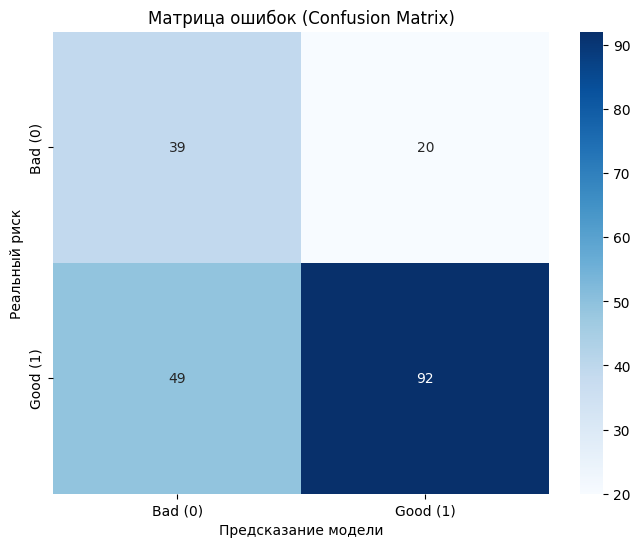

In [16]:
f_y_pred = evaluate_fuzzy_system(X_test, risk_sim)
print(classification_report(y_test, f_y_pred, target_names=["Bad", "Good"]))

cm = confusion_matrix(y_test, f_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=text_labels,
    yticklabels=text_labels,
)

plt.xlabel("Предсказание модели")
plt.ylabel("Реальный риск")
plt.title("Матрица ошибок (Confusion Matrix)")
plt.show()

Несмотря на чуть меньший F1-score, эта модель имеет более высокую объяснимость.

Нечеткая система позволяет банку аргументированно отказывать в кредите, опираясь на финансовое состояние клиента.

#### Отображение пространства решений для нечеткой системы при savings = 0 и savings = 1

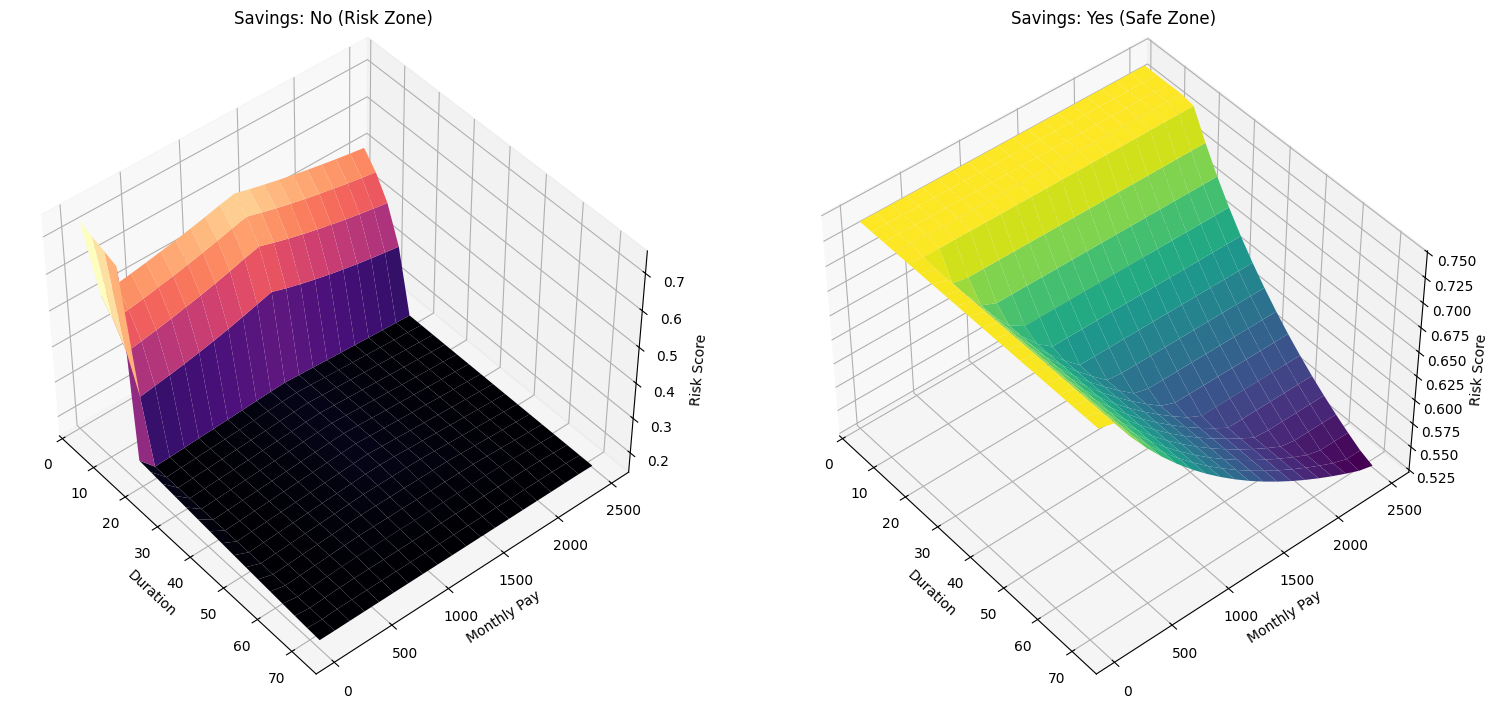

In [17]:
# Сетка координат
x_range = np.linspace(d_min, d_max, 20)
y_range = np.linspace(m_min, m_max, 20)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

# Создаем две матрицы для Z (сбережения 0 и 1)
z_no_savings = np.zeros_like(x_mesh)
z_has_savings = np.zeros_like(x_mesh)

# Заполняем данными
for i in range(len(x_range)):
    for j in range(len(y_range)):
        # Общие входы
        risk_sim.input["duration"] = x_mesh[i, j]
        risk_sim.input["monthly_pay"] = y_mesh[i, j]

        # Считаем для варианта "Низкие сбережения" (0)
        risk_sim.input["savings"] = 0
        risk_sim.compute()
        z_no_savings[i, j] = risk_sim.output["risk"]

        # Считаем для варианта "Высокие сбережения" (1)
        risk_sim.input["savings"] = 1
        risk_sim.compute()
        z_has_savings[i, j] = risk_sim.output["risk"]

# Визуализация
fig = plt.figure(figsize=(16, 7))

# График 1: Без сбережений
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf1 = ax1.plot_surface(x_mesh, y_mesh, z_no_savings, cmap="magma", antialiased=True)
ax1.set_title("Savings: No (Risk Zone)")
ax1.set_xlabel("Duration")
ax1.set_ylabel("Monthly Pay")
ax1.set_zlabel("Risk Score")
ax1.view_init(45, -40)

# График 2: Со сбережениями
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
surf2 = ax2.plot_surface(
    x_mesh, y_mesh, z_has_savings, cmap="viridis", antialiased=True
)
ax2.set_title("Savings: Yes (Safe Zone)")
ax2.set_xlabel("Duration")
ax2.set_ylabel("Monthly Pay")
ax2.set_zlabel("Risk Score")
ax2.view_init(45, -40)

plt.tight_layout()
plt.show()

Нечеткая модель демонстрирует адаптивное поведение:
- При отсутствии сбережений (savings = 0) система переходит в режим жесткого ограничения рисков, блокируя заявки с длительным сроком.
- При наличии накоплений (savings = 1) модель становится лояльной, допуская кредитование при средних параметрах нагрузки, но сохраняет отказ для экстремальных сочетаний (Duration > 50 и Monthly Pay > 2000).

#### Отображение пространства решений для дерева решений при Checking account_unknown = 0 и Checking account_unknown = 1

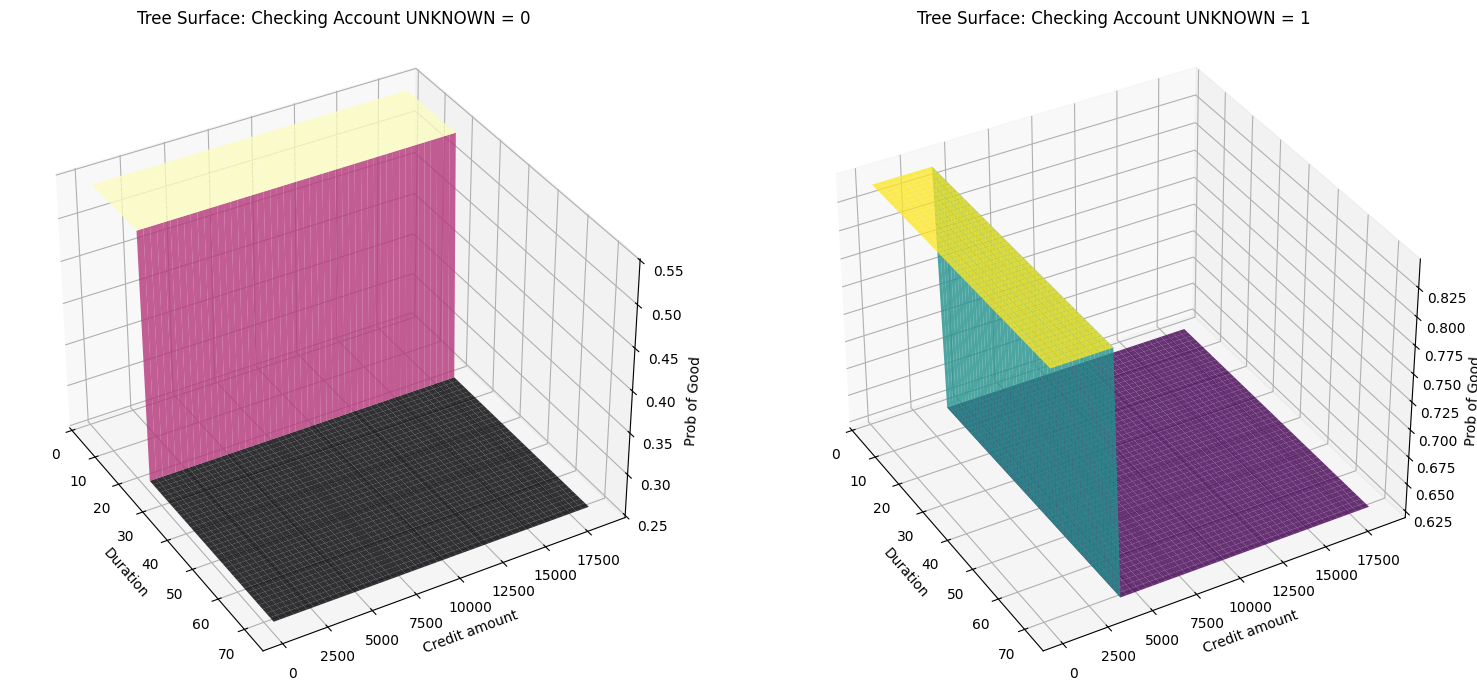

In [18]:
# Важно: используем имена колонок, что и при обучении tree_model
template = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Заполняем медианами остальные признаки (Age, Job и т.д.), чтобы они были стабильны
for col in template.columns:
    if col in df.columns:
        template[col] = df[col].median()

x_range = np.linspace(df["Duration"].min(), df["Duration"].max(), 50)
y_range = np.linspace(df["Credit amount"].min(), df["Credit amount"].max(), 50)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

z_unknown_0 = np.zeros_like(x_mesh)  # Для Checking account_unknown = 0
z_unknown_1 = np.zeros_like(x_mesh)  # Для Checking account_unknown = 1

# Проходим по сетке и получаем вероятности от дерева
for i in range(len(x_range)):
    for j in range(len(y_range)):
        # Создаем временную строку для предсказания
        row = template.copy()
        row["Duration"] = x_mesh[i, j]
        row["Credit amount"] = y_mesh[i, j]

        # Данные о счете есть (unknown = 0)
        row["Checking account_unknown"] = 0
        z_unknown_0[i, j] = tree_model.predict_proba(row)[0][1]

        # Данных о счете нет (unknown = 1)
        row["Checking account_unknown"] = 1
        z_unknown_1[i, j] = tree_model.predict_proba(row)[0][1]

fig = plt.figure(figsize=(16, 7))

# График для Checking account_unknown = 0
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(x_mesh, y_mesh, z_unknown_0, cmap="magma", alpha=0.8)
ax1.set_title("Tree Surface: Checking Account UNKNOWN = 0")
ax1.set_xlabel("Duration")
ax1.set_ylabel("Credit amount")
ax1.set_zlabel("Prob of Good")
ax1.view_init(35, -30)

# График для Checking account_unknown = 1
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(x_mesh, y_mesh, z_unknown_1, cmap="viridis", alpha=0.8)
ax2.set_title("Tree Surface: Checking Account UNKNOWN = 1")
ax2.set_xlabel("Duration")
ax2.set_ylabel("Credit amount")
ax2.set_zlabel("Prob of Good")
ax2.view_init(35, -30)

plt.tight_layout()
plt.show()

Что мы видим на этих графиках:
1. "Обрывы" вместо "склонов". У нечеткой системы плавные переходы. У дерева решений - ступеньки, что соответствует визуализации условий if-else.
2. Линия "разлома" на оси Duration (примерно на уровне 22–30) — это тот самый узел дерева, который отделяет краткосрочные кредиты от долгосрочных.
3. Весь график слева находится в "подвале" значения Prob of Good от 0.25 до 0.55. Даже при идеальном сроке и сумме дерево не дает этому клиенту больше 55% шансов на получение кредита.
4. Весь график справа имеет более высокую вероятность выдачи кредита. Нижняя точка здесь (0.625) выше, чем самая высокая точка на левом графике.
5. Для дерева решений признак Checking Account Unknown является основным предиктором. Если данных о счете нет, клиент автоматически становится более надежным.

Обратите внимание, что склоны на графике дерева решений всегда параллельны осям. Это особенность классических деревьев: они делят пространство признаков на прямоугольные области. Именно поэтому дерево не может поймать тонкие диагональные зависимости (в отличие от нечеткой логики).

Поверхность решения для нечеткой системы больше похожа на ландшафт. Она более гибкая и устойчивая.

Дерево решений формирует пространство решений из блоков. Оно очень точное на конкретных данных, но при малейшем сдвиге признака (на 1 месяц или 1 марку) произойдет смещение значений целевого признака.